# Integrative Industry Synthesis Project: The German Energy Market
## by <i>Andreas Grotz</i>





## Table of Contents
- [Introduction](#intro)
- [Loading the Modules](#mod)
- [Importing and Preparing the Data](#data)
- [Predicting the Energy Price](#price)
- [Predicting the Residual Load](#residual)
- [Forecasting the Total Load](#total)
- [Workflows and Use Cases](#flows)
- [Limitations and Future Improvements](#lim)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we ...

TODO: Explain merit order system (https://www.smard.de/page/en/wiki-article/5884/5840/this-is-how-the-electricity-market-works)


<a id='mod'></a>
### Loading the Modules

In this section, we import required Python modules.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip install scipy
#!pip install statsmodels
#!pip install scikit-learn
#!pip install yfinance 
#!pip3 install torch torchvision
#!pip3 install torcheval

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torcheval.metrics import R2Score
import yfinance as yf

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# We set a fixed seed of the random generator for better reprodicibility, see
# https://docs.pytorch.org/docs/stable/notes/randomness.html#reproducibility
torch.manual_seed(0);

<a id='data'></a>
### Importing and Preparing the Data

The first file we import was downloaded from the regulator for the German energy market (https://www.smard.de/home/downloadcenter/download-marktdaten/):

In [5]:
df_consumption = pd.read_csv('Realisierter_Stromverbrauch_201501010000_202412310000_Tag.csv', sep=";", thousands=".", decimal=','
                            , parse_dates=["Datum von", "Datum bis"], date_format='%d.%m.%Y')

In [6]:
df_consumption.head()

,Datum von,Datum bis,Netzlast [MWh] Berechnete Auflösungen,Netzlast inkl. Pumpspeicher [MWh] Berechnete Auflösungen,Pumpspeicher [MWh] Berechnete Auflösungen,Residuallast [MWh] Berechnete Auflösungen
0,2015-01-01,2015-01-02,1106343.98,1133468.30,27124.32,761712.01
1,2015-01-02,2015-01-03,1299202.20,1334453.56,35251.37,691721.64
2,2015-01-03,2015-01-04,1223466.05,1258747.92,35281.87,745091.11
3,2015-01-04,2015-01-05,1177896.00,1202337.75,24441.75,767345.50
4,2015-01-05,2015-01-06,1425927.50,1451660.75,25733.25,1172036.25


It contains daily values for the total network load in the grid ("Netzlast") denoted in MegaWatt hours (MWh), as well as the residual load ("Residuallast") that has been generated by conventional power plants (natural gas, coal, nuclear, etc.) as opposed to renewable energies. We only require these two columns as well as the date label. Hence we remove the other columns, and use English column headers:

In [7]:
df_consumption.drop(['Datum bis', 'Netzlast [MWh] Berechnete Auflösungen', 'Pumpspeicher [MWh] Berechnete Auflösungen'], axis=1, inplace=True)
df_consumption.columns = ['Date', 'Total_Load', 'Residual_Load']

Next, we translate the residual load into a percentage of the total load. Percentages are constrainted between zero and one, which is not ideal for artificial intelligence methods. We therefore transform the percentage number to an unconstrained variable by using the cumulative normal probability function. 

In [8]:
df_consumption['Residual_Fraction'] = df_consumption['Residual_Load'] / df_consumption['Total_Load']
df_consumption.drop(['Residual_Load'], axis=1, inplace=True)

In [9]:
df_consumption['Residual_Fraction_Probit'] = df_consumption['Residual_Fraction'].apply(stats.norm.ppf)

In [10]:
df_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      3653 non-null   datetime64[ns]
 1   Total_Load                3653 non-null   float64       
 2   Residual_Fraction         3653 non-null   float64       
 3   Residual_Fraction_Probit  3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 114.3 KB


There are no missing values in these data. In addition, the time series plots below show that there is a strong seasonal pattern in the data (higher power consumption in winter than in summer). There is also a decreasing trend in the residual load, which is due to a trend of installing more renewable energy generators (mostly solar and wind). 

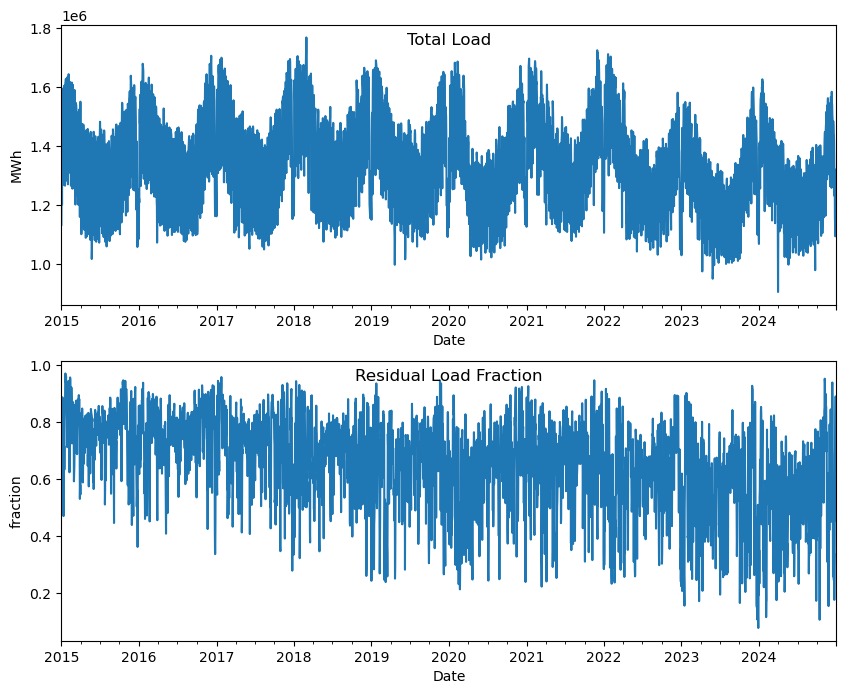

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
df_consumption.plot(x='Date', y='Total_Load', ax=ax[0]);
df_consumption.plot(x='Date', y='Residual_Fraction', ax=ax[1]);
ax[0].set(ylabel='MWh')
ax[0].set_title('Total Load', y=1.0, pad=-14)
ax[1].set(ylabel='fraction')
ax[1].set_title('Residual Load Fraction', y=1.0, pad=-14)
ax[0].get_legend().remove()
ax[1].get_legend().remove()
plt.show()

In [12]:
df_consumption.corr()

,Date,Total_Load,Residual_Fraction,Residual_Fraction_Probit
Date,1.000000,-0.215214,-0.426520,-0.427289
Total_Load,-0.215214,1.000000,0.232879,0.248119
Residual_Fraction,-0.426520,0.232879,1.000000,0.993528
Residual_Fraction_Probit,-0.427289,0.248119,0.993528,1.000000


Our second file is also sourced from the German regulator, using the same URL as for the first file. It contains daily values for wholesale power prices per MWh:

In [13]:
df_energyprices = pd.read_csv('Gro_handelspreise_201501010000_202412310000_Tag.csv', sep=";", decimal=','
                            , parse_dates=["Datum von", "Datum bis"], date_format='%d.%m.%Y', na_values='-')

In [14]:
df_energyprices.head()

,Datum von,Datum bis,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,∅ Anrainer DE/LU [€/MWh] Berechnete Auflösungen,Belgien [€/MWh] Berechnete Auflösungen,Dänemark 1 [€/MWh] Berechnete Auflösungen,Dänemark 2 [€/MWh] Berechnete Auflösungen,Frankreich [€/MWh] Berechnete Auflösungen,Niederlande [€/MWh] Berechnete Auflösungen,Norwegen 2 [€/MWh] Berechnete Auflösungen,Österreich [€/MWh] Berechnete Auflösungen,Polen [€/MWh] Berechnete Auflösungen,Schweden 4 [€/MWh] Berechnete Auflösungen,Schweiz [€/MWh] Berechnete Auflösungen,Tschechien [€/MWh] Berechnete Auflösungen,DE/AT/LU [€/MWh] Berechnete Auflösungen,Italien (Nord) [€/MWh] Berechnete Auflösungen,Slowenien [€/MWh] Berechnete Auflösungen,Ungarn [€/MWh] Berechnete Auflösungen
0,2015-01-01,2015-01-02,NaN,NaN,NaN,16.31,18.20,NaN,NaN,27.23,NaN,NaN,24.91,36.63,21.70,NaN,NaN,30.31,33.09
1,2015-01-02,2015-01-03,NaN,NaN,NaN,4.97,11.62,NaN,NaN,27.55,NaN,NaN,24.99,41.61,12.25,NaN,NaN,45.18,43.78
2,2015-01-03,2015-01-04,NaN,NaN,NaN,15.29,15.50,NaN,NaN,27.18,NaN,NaN,24.06,36.59,18.10,NaN,NaN,43.98,38.32
3,2015-01-04,2015-01-05,NaN,NaN,NaN,21.06,21.55,NaN,NaN,28.08,NaN,NaN,28.25,31.72,12.83,NaN,NaN,38.21,40.36
4,2015-01-05,2015-01-06,NaN,NaN,44.83,38.00,38.41,44.43,41.71,34.93,NaN,NaN,38.45,47.39,38.55,35.86,52.58,42.69,44.70


In [15]:
df_energyprices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   Datum von                                             3653 non-null   datetime64[ns]
 1   Datum bis                                             3653 non-null   datetime64[ns]
 2   Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen  2284 non-null   float64       
 3   ∅ Anrainer DE/LU [€/MWh] Berechnete Auflösungen       1869 non-null   float64       
 4   Belgien [€/MWh] Berechnete Auflösungen                3649 non-null   float64       
 5   Dänemark 1 [€/MWh] Berechnete Auflösungen             3653 non-null   float64       
 6   Dänemark 2 [€/MWh] Berechnete Auflösungen             3653 non-null   float64       
 7   Frankreich [€/MWh] Berechnete Auflösungen             3649 non-null   float64 

There are columns for several European energy market regions, of which only two are relevant for the German market. Hence we drop the other columns and we use English column headers:

In [16]:
cols_to_drop = [c for c in df_energyprices.columns if c not in ['Datum von', 'Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen', 'DE/AT/LU [€/MWh] Berechnete Auflösungen']]
df_energyprices.drop(cols_to_drop, axis=1, inplace=True)
df_energyprices.columns = ['Date', 'DE/LU', 'DE/AT/LU']

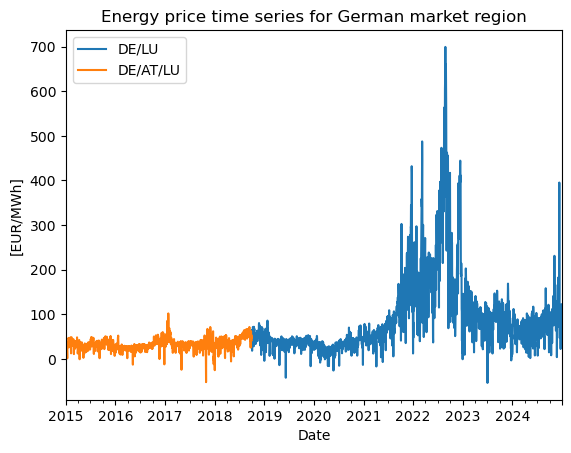

In [17]:
df_energyprices.plot(x='Date');
plt.title('Energy price time series for German market region')
plt.xlabel('Date')
plt.ylabel('[EUR/MWh]')
plt.show()

As one can see in the above plot, there seems to have been a switch of market region cuts in 2018. Germany (DE) moved from a common region with Austria (AT) and Luxemburg (LU), to a common region with Luxemburg only. Indeed, the two columns have no overlapping values:

In [18]:
df_energyprices[df_energyprices['DE/AT/LU'].notna() & df_energyprices['DE/LU'].notna()]

,Date,DE/LU,DE/AT/LU


We therefore merge the two columns into a single column with power prices for the German market:

In [19]:
def get_notna_price(row):
    if not np.isnan(row['DE/LU']):
        return row['DE/LU']
    else:
        return row['DE/AT/LU']

In [20]:
df_energyprices['Power_Price'] = df_energyprices.apply(get_notna_price, axis=1)

In [21]:
df_energyprices.drop(['DE/LU', 'DE/AT/LU'], axis=1, inplace=True)
df_energyprices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3653 non-null   datetime64[ns]
 1   Power_Price  3649 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


There are only four missing values at the begin of the 2015-2024 time series, which we drop from the frame:

In [22]:
df_energyprices.dropna(axis=0, inplace=True)
df_energyprices.head()

,Date,Power_Price
4,2015-01-05,35.86
5,2015-01-06,33.88
6,2015-01-07,38.72
7,2015-01-08,28.48
8,2015-01-09,24.25


The third file was obtained from the German Meteorological Service (https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/tageswerte_KL_01691_18580101_20241231_hist.zip). It contains daily meteorological data for the city of Goettingen, which is close to the geographical center of Germany:

In [23]:
df_weather = pd.read_csv('produkt_klima_tag_18580101_20241231_01691.txt', sep=";", parse_dates=["MESS_DATUM"], date_format='%Y%m%d')

In [24]:
df_weather.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,1691,1858-01-01,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,-999.0,1017.2,1.5,96.0,-999.0,-999.0,-999.0,eor
1,1691,1858-01-02,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,5.7,1016.5,-0.7,96.0,-999.0,-999.0,-999.0,eor
2,1691,1858-01-03,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,-999.0,1018.9,-1.1,92.0,-999.0,-999.0,-999.0,eor
3,1691,1858-01-04,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,2.7,1018.6,-9.5,89.0,-999.0,-999.0,-999.0,eor
4,1691,1858-01-05,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,2.4,1012.4,-7.6,77.0,-999.0,-999.0,-999.0,eor


The file contains several columns, which are described in detail in a manual (https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/DESCRIPTION_obsgermany-climate-daily-kl_en.pdf). We keep the columns for mean wind speed, hours of sunshine, and mean temperature, along with the date column. We again rename using English column headers:

In [25]:
cols_to_drop = [c for c in df_weather.columns if c not in ['MESS_DATUM', 'FM', 'SDK', 'TMK']]
df_weather.drop(cols_to_drop, axis=1, inplace=True)
df_weather.columns = ['Date', 'Wind_Speed', 'Sunshine_Hours', 'Temperature']

The file encodes NA values with the float value -999.0, so we need to clean it accordingly. Moreover, we can restrict to the 2015-2024 period:

In [26]:
df_weather = df_weather[(df_weather.Date >= '2015-01-01') & (df_weather.Date <= '2024-12-31')]
df_weather.replace(float(-999.0),np.nan, inplace=True)
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3653 entries, 55672 to 59324
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            3653 non-null   datetime64[ns]
 1   Wind_Speed      3615 non-null   float64       
 2   Sunshine_Hours  3653 non-null   float64       
 3   Temperature     3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 142.7 KB


There is a small number of 38 missing values for wind speed. In order to keep a daily series, we impute with the mean value rather than dropping these rows. Mean is the most straighforward method, and the impact should be limited given the small number of NAs. 

In [27]:
df_weather["Wind_Speed"] = df_weather["Wind_Speed"].fillna(df_weather["Wind_Speed"].mean())

In [28]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3653 entries, 55672 to 59324
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            3653 non-null   datetime64[ns]
 1   Wind_Speed      3653 non-null   float64       
 2   Sunshine_Hours  3653 non-null   float64       
 3   Temperature     3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 142.7 KB


As one would expect, there are clear seasonality pattern in the meteorological variables:

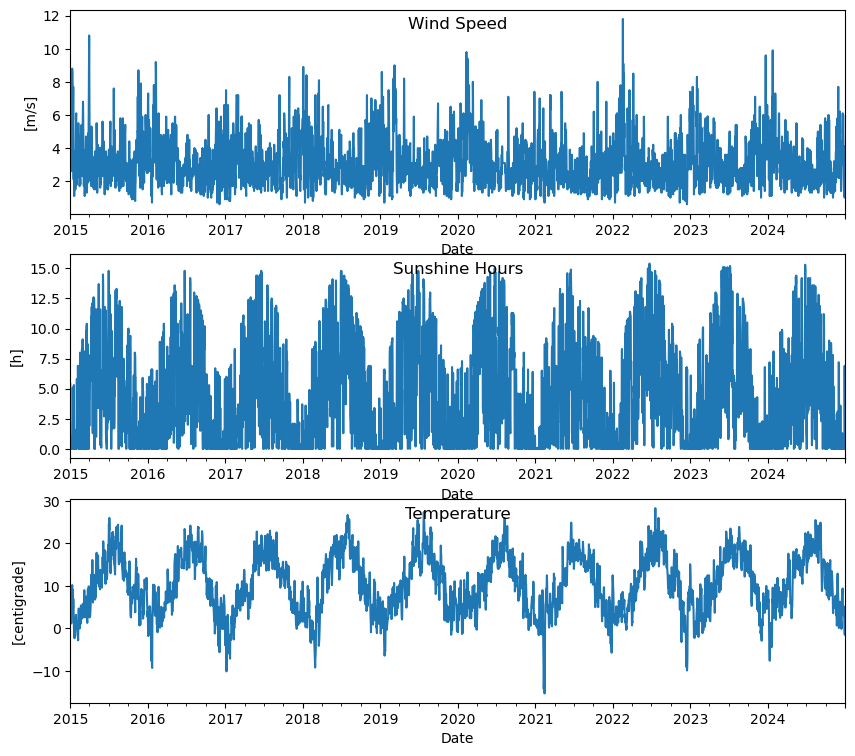

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(10, 9))
df_weather.plot(x='Date', y='Wind_Speed', ax=ax[0]);
df_weather.plot(x='Date', y='Sunshine_Hours', ax=ax[1]);
df_weather.plot(x='Date', y='Temperature', ax=ax[2]);
ax[0].set(ylabel='[m/s]')
ax[0].set_title('Wind Speed', y=1.0, pad=-14)
ax[1].set(ylabel='[h]')
ax[1].set_title('Sunshine Hours', y=1.0, pad=-14)
ax[2].set(ylabel='[centigrade]')
ax[2].set_title('Temperature', y=1.0, pad=-14)
ax[0].get_legend().remove()
ax[1].get_legend().remove()
ax[2].get_legend().remove()
plt.show()

In [30]:
df_weather.corr()

,Date,Wind_Speed,Sunshine_Hours,Temperature
Date,1.000000,-0.053106,0.021969,0.056636
Wind_Speed,-0.053106,1.000000,-0.256726,-0.131434
Sunshine_Hours,0.021969,-0.256726,1.000000,0.467990
Temperature,0.056636,-0.131434,0.467990,1.000000


The last dataset we consider are daily prices for commodities used in conventional powerplants. The main resources for conventional energy in Germany are natural gas and coal. 
- For coal prices, a reasonable datasource would be the front contract price of the API2 future traded on the Intercontinental Exchange (see https://www.ice.com/products/243/API2-Rotterdam-Coal-Futures). Unfortunately, we haven't found any open-source data for for that future.
- For natural gas we can use the level of the TTF future traded on the ICE (see https://www.ice.com/products/27996665/Dutch-TTF-Natural-Gas-Futures), which are representative for wholesale prices of natural gas in Europe. We obtain these via the Yahoo Finance API:

In [31]:
# Note: The timeseries has already been downloaded and are stored in the ttf.csv file in this project.
# By setting the below variable to True, it can be reloaded from Yahoo Finance
reload_data_imports = False
if(reload_data_imports):
    df_natgasprices = yf.download(tickers=["TTF=F"], start='2015-01-01', end='2024-12-31')
    df_natgasprices.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
    df_natgasprices.columns = ['Gas_Price']
    df_natgasprices.to_csv('ttf.csv')

In [32]:
df_natgasprices = pd.read_csv("ttf.csv")
df_natgasprices.Date = pd.to_datetime(df_natgasprices.Date)
df_natgasprices.set_index('Date', inplace=True)
df_natgasprices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1808 entries, 2017-10-23 to 2024-12-30
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gas_Price  1808 non-null   float64
dtypes: float64(1)
memory usage: 28.2 KB


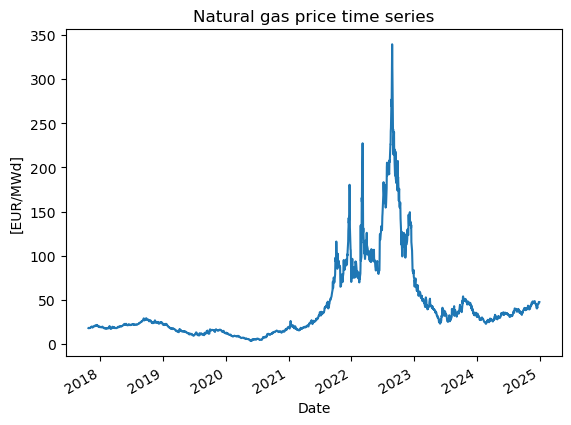

In [33]:
df_natgasprices.plot(legend=False);
plt.xlabel('Date')
plt.ylabel('[EUR/MWd]')
plt.title('Natural gas price time series')
plt.show()

Unfortunately, the time series available for the TTF future on Yahoo Finance does not cover the full period 2015-2024. In addition, it only contains values on ICE trading days. Hence prices on weekends and holidays are missing, while we have power prices available for each calendar day. Arguably, it would be better to use levels of the EEX Gas Spot (https://www.eex.com/en/markets/natural-gas/gas-spot), which also allows to trade on weekends, but these are not available open-source.

<a id='price'></a>
### Predicting the Energy Price

Our first task is to predict the power price from independent variables. Our hypothesis is that this is mainly driven by the natural gas price and the fraction of power generated by conventional plants. We start by preparing are specific dataframe:

In [34]:
df_pricing = df_energyprices.copy()

In [35]:
df_natgasprices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1808 entries, 2017-10-23 to 2024-12-30
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gas_Price  1808 non-null   float64
dtypes: float64(1)
memory usage: 28.2 KB


In [36]:
df_pricing = df_pricing.join(df_natgasprices, on='Date', how='inner')

In [37]:
df_pricing = df_pricing.join(df_consumption[['Date','Residual_Fraction_Probit']].set_index('Date'), on='Date', how='inner').set_index('Date')
df_pricing.dropna(axis=0, inplace=True)

In [38]:
df_pricing.head()

,Power_Price,Gas_Price,Residual_Fraction_Probit
Date,,,
2017-10-23,41.42,18.090000,0.774489
2017-10-24,38.12,17.959999,0.784541
2017-10-25,33.77,18.110001,0.370906
2017-10-26,40.43,18.070000,0.633270
2017-10-27,30.45,18.150000,0.250449


In [39]:
df_pricing.corr()

,Power_Price,Gas_Price,Residual_Fraction_Probit
Power_Price,1.000000,0.921400,0.195871
Gas_Price,0.921400,1.000000,-0.011977
Residual_Fraction_Probit,0.195871,-0.011977,1.000000


Looking at the correlation matrix, there is indeed a strong relationship between the power price and the explanatory variables. We validate this by using statistical tests for the correlation, which we already used in the second capstone project:

In [40]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Gas_Price'], alternative='two-sided')

PearsonRResult(statistic=np.float64(0.9214004468722926), pvalue=np.float64(0.0))

In [41]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Residual_Fraction_Probit'], alternative='two-sided')

PearsonRResult(statistic=np.float64(0.19587096569074663), pvalue=np.float64(4.303426862878885e-17))

In [42]:
stats.pearsonr(df_pricing['Gas_Price'], df_pricing['Residual_Fraction_Probit'], alternative='two-sided')

PearsonRResult(statistic=np.float64(-0.011977249006577144), pvalue=np.float64(0.6107903178318472))

The tests show that we can accept the alternative hypothesis of non-zero correlation between power price and explanatory variables at e.g. the 99% level. At the same time, we need to accept the null hypothesis of zero correlation among the two explanatory variables. This suggests that a linear regression model could be a good choice for the prediction. So let us split the data into a train and test set, and let us fit a linear regression model using the same packages as in the Statistics for Data Analysis nanodegree:

In [43]:
cols = [c for c in df_pricing.columns if c != 'Power_Price']
X_pr_train, X_pr_test, y_pr_train, y_pr_test = train_test_split(df_pricing[cols], df_pricing.iloc[:,:][['Power_Price']]
                                                        , test_size = 0.1, shuffle=False)

In [44]:
pr_model = sm.OLS(y_pr_train, X_pr_train.astype(float))
pr_results = pr_model.fit()

In [45]:
print(pr_results.summary2())

                        Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): 0.949     
Dependent Variable:     Power_Price      AIC:                         15755.7824
Date:                   2026-05-19 20:04 BIC:                         15766.5714
No. Observations:       1627             Log-Likelihood:              -7875.9   
Df Model:               2                F-statistic:                 1.508e+04 
Df Residuals:           1625             Prob (F-statistic):          0.00      
R-squared (uncentered): 0.949            Scale:                       939.02    
---------------------------------------------------------------------------------
                             Coef.   Std.Err.     t      P>|t|    [0.025   0.975]
---------------------------------------------------------------------------------
Gas_Price                    1.8590    0.0133  139.9005  0.0000   1.8330   1.8851
Residual_Fraction_Probit    39.3230    1.4290   2

The model fits the training data very well, we can accept the alternative hypothesis that the model is better that a constant at any sensible level. The R-squared of 95% indicates that the bulk of the observed variance is explained by the model.

Next, let us see how good the model extends to the test data by comparing preidctions with actual realizations:

In [46]:
pr_acts = []
pr_preds = []
pr_residuals = []
mae = 0
for i in range(len(X_pr_test.index)):
    pr_pred = (pr_results.params.to_numpy() * X_pr_test.iloc[i]).sum()
    pr_act = y_pr_test.iloc[i].sum()
    pr_residual = pr_act-pr_pred
    pr_acts.append(pr_act)
    pr_preds.append(pr_pred)
    pr_residuals.append(pr_residual)
pr_acts = np.array(pr_acts)
pr_preds = np.array(pr_preds)
pr_residuals = np.array(pr_residuals)

In [47]:
r2_score(pr_acts, pr_preds)

0.4718239013086314

In [48]:
print(f'Mean absolute error: {np.mean(np.abs(pr_preds-pr_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(pr_preds/pr_acts-1))}')

Mean absolute error: 17.140733879415983
Mean abs of relative errors base: 0.19026719902203526


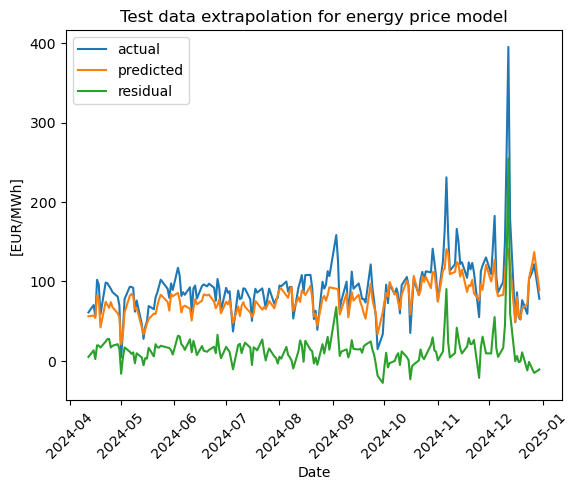

In [49]:
plt.plot(X_pr_test.index, pr_acts, label ='actual');
plt.plot(X_pr_test.index, pr_preds, label ='predicted');
plt.plot(X_pr_test.index, pr_residuals, label ='residual');
plt.legend()
plt.xticks(rotation=45);
plt.xlabel('Date')
plt.ylabel('[EUR/MWh]')
plt.title('Test data extrapolation for energy price model')
plt.show()

The R-squared of explained vs observed variance reduces to 47%, so the extrapolation to the test set is not bad, but also not great. The mean absolute error over the test period is around 17 EUR, and the mean relative error around 20%.

We suppose that this result could be improved by including prices for coal into the explanatory variables and by using commoditiy prices for each calander day, rather than the business day resolution of the TTF future. These data require to purchase a license however and are therefore beyond the scope of our project.

<a id='residual'></a>
### Predicting the Residual Load Fraction

Our second task is to predict the residual load fraction, which enters into the price prediction. Recall that the residual load is the share of the total load that cannot be produced by renewable sources and hence needs to be provided by conventional power plants. Our approach is therefore to use as explanatory variables the total power load, as well as the meteorological variables related to productivity of renewables. As mentioned earlier, we will predict the unconstrained probit version of the residual fraction, as this is more amenable to AI methods.

In [50]:
df_residualload = df_weather[['Date','Wind_Speed', 'Sunshine_Hours', 'Temperature']]

In [51]:
df_residualload = df_residualload.join(df_consumption[['Date','Total_Load','Residual_Fraction_Probit']].set_index('Date'), on='Date', how='inner')

As observed during data preparation, there is both a seasonality and a trend in the residual load fraction. The seasonality should already be covered by the seasonality in the meteorological variables. In order to account for the trend, we explicitely add the calendar year as an explanatory variable.

In [52]:
df_residualload['Year'] =  df_residualload['Date'].dt.year
df_residualload.dropna(axis=0, inplace=True)
df_residualload.set_index('Date', inplace=True)

In [53]:
df_residualload.corr()

,Wind_Speed,Sunshine_Hours,Temperature,Total_Load,Residual_Fraction_Probit,Year
Wind_Speed,1.000000,-0.256726,-0.131434,0.198482,-0.644439,-0.039127
Sunshine_Hours,-0.256726,1.000000,0.467990,-0.295668,-0.056892,0.028479
Temperature,-0.131434,0.467990,1.000000,-0.431162,-0.155259,0.035341
Total_Load,0.198482,-0.295668,-0.431162,1.000000,0.248119,-0.202645
Residual_Fraction_Probit,-0.644439,-0.056892,-0.155259,0.248119,1.000000,-0.433956
Year,-0.039127,0.028479,0.035341,-0.202645,-0.433956,1.000000


The correlations are less pronounced as in the price case, and explanatory variables are also correlated among each other. Let us still start with fitting a linear regression model:

In [54]:
cols = [c for c in df_residualload.columns if c != 'Residual_Fraction_Probit']
X_rl_train, X_rl_test, y_rl_train, y_rl_test = train_test_split(df_residualload[cols], df_residualload[['Residual_Fraction_Probit']]
                                                        , test_size = 0.1, shuffle=False)

In [55]:
model = sm.OLS(y_rl_train, X_rl_train.astype(float))
results = model.fit()

In [56]:
print(results.summary2())

                            Results: Ordinary least squares
Model:                  OLS                      Adj. R-squared (uncentered): 0.804    
Dependent Variable:     Residual_Fraction_Probit AIC:                         1184.5247
Date:                   2026-05-19 20:04         BIC:                         1215.0133
No. Observations:       3287                     Log-Likelihood:              -587.26  
Df Model:               5                        F-statistic:                 2706.    
Df Residuals:           3282                     Prob (F-statistic):          0.00     
R-squared (uncentered): 0.805                    Scale:                       0.083824 
-------------------------------------------------------------------------------------------
                        Coef.      Std.Err.        t         P>|t|       [0.025      0.975]
-------------------------------------------------------------------------------------------
Wind_Speed             -0.2348       0.0036     

The R-squared of 80% is not too bad, but as expected there is a multicollinearity issue. Also, the calender year seems not statistically significant, despite the observed trend. Let us no look at the extrapolation of the model to the test data:

In [57]:
rl_lin_acts = []
rl_lin_exps = []
rl_lin_residuals = []
for i in range(len(X_rl_test.index)):
    rl_lin_exp = stats.norm.cdf((results.params.to_numpy() * X_rl_test.iloc[i]).sum())
    rl_lin_act = stats.norm.cdf(y_rl_test.iloc[i].sum())
    rl_lin_residual = rl_lin_act-rl_lin_exp
    rl_lin_acts.append(rl_lin_act)
    rl_lin_exps.append(rl_lin_exp)
    rl_lin_residuals.append(rl_lin_residual)
rl_lin_acts = np.array(rl_lin_acts)
rl_lin_exps = np.array(rl_lin_exps)
rl_lin_residual = np.array(rl_lin_residual)

In [58]:
r2_score(rl_lin_acts, rl_lin_exps)

0.20566519069441136

In [59]:
print(f'Mean absolute error: {np.mean(np.abs(rl_lin_exps-rl_lin_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(rl_lin_exps/rl_lin_acts-1))}')

Mean absolute error: 0.12229503031260612
Mean abs of relative errors base: 0.309215049353866


The extrapolation of the linear regression is rather poor, with an R-squared of only 20% and a mean relative error above 30%. We therefore consider another model that goes beyond a linear approach. Namely, we use a decision tree regression. Similar to our third capstone project, we fit regressors to the training data along the cost-complexity pruning path, and then choose the one with the best performance on the test data.

In [60]:
decisionTreeRegressor = DecisionTreeRegressor()
path = decisionTreeRegressor.cost_complexity_pruning_path(X_rl_train, y_rl_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [61]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_rl_train, y_rl_train)
    clfs.append(clf)

In [62]:
train_scores = [clf.score(X_rl_train, y_rl_train) for clf in clfs]
test_scores = [clf.score(X_rl_test, y_rl_test) for clf in clfs]

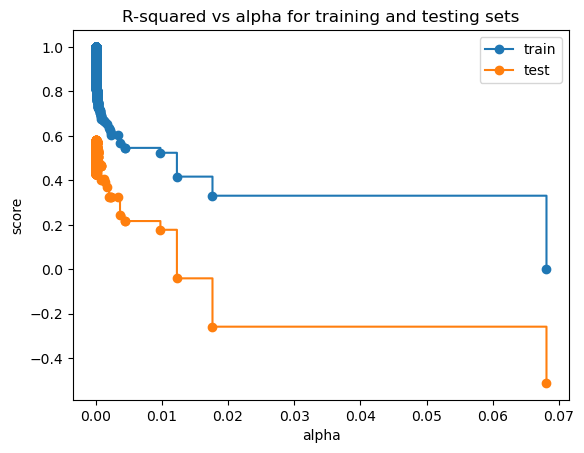

In [63]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("score")
ax.set_title("R-squared vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

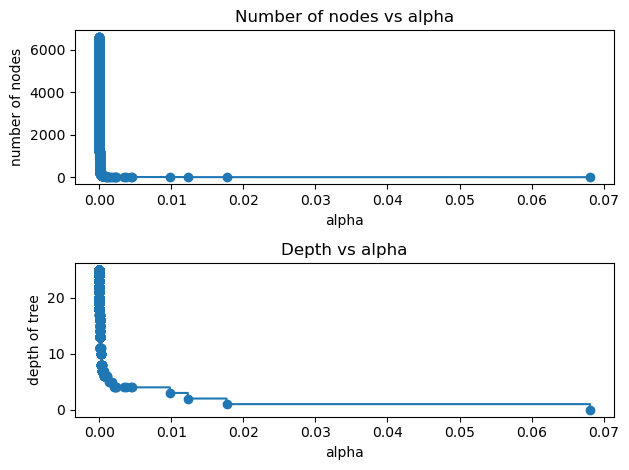

In [64]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [65]:
best_idx = np.argmax(test_scores)
alpha_opt = ccp_alphas[best_idx]
print(f'Best alpha for pruning: {alpha_opt}')
decisionTreeRegressor = clfs[best_idx]

Best alpha for pruning: 0.00012067146294574243


In [66]:
print(f'Train score: {train_scores[best_idx]}, Test score: {test_scores[best_idx]}')

Train score: 0.8142775391954307, Test score: 0.5810860983840129


In [67]:
print(f'Nodes: {node_counts[best_idx]}, Depth: {depth[best_idx]}')

Nodes: 231, Depth: 11


The decision tree regressor achieves an R-squared of around 80% on the training data, which is quite similar to the linear regressor. However, it extrapolates much better to the test data with an R-squared close to 60% and a mean relative error of 20%:

In [68]:
rl_dtr_acts = []
rl_dtr_exps = []
rl_dtr_residuals = []
for i in range(len(X_rl_test.index)):
    rl_dtr_exp = stats.norm.cdf(decisionTreeRegressor.predict(X_rl_test.iloc[[i]]))
    rl_dtr_act = stats.norm.cdf(y_rl_test.iloc[i])
    rl_dtr_residual = rl_dtr_act-rl_dtr_exp
    rl_dtr_acts.append(rl_dtr_act)
    rl_dtr_exps.append(rl_dtr_exp)
    rl_dtr_residuals.append(rl_dtr_residual)
rl_dtr_acts = np.array(rl_dtr_acts)
rl_dtr_exps = np.array(rl_dtr_exps)
rl_dtr_residuals = np.array(rl_dtr_residuals)

In [69]:
r2_score(rl_dtr_acts, rl_dtr_exps)

0.5779781852700934

In [70]:
print(f'Mean absolute error: {np.mean(np.abs(rl_dtr_exps-rl_dtr_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(rl_dtr_exps/rl_dtr_acts-1))}')

Mean absolute error: 0.08713976171219323
Mean abs of relative errors base: 0.2006835328620551


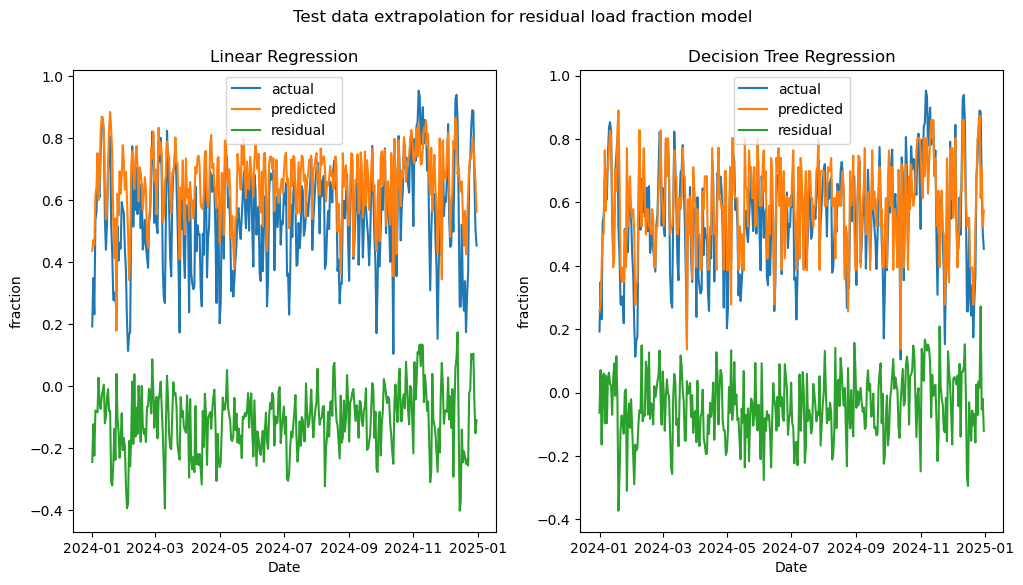

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Test data extrapolation for residual load fraction model')
ax[0].plot(X_rl_test.index, rl_lin_acts, label ='actual');
ax[0].plot(X_rl_test.index, rl_lin_exps, label ='predicted');
ax[0].plot(X_rl_test.index, rl_lin_residuals, label ='residual');
ax[1].plot(X_rl_test.index, rl_dtr_acts, label ='actual');
ax[1].plot(X_rl_test.index, rl_dtr_exps, label ='predicted');
ax[1].plot(X_rl_test.index, rl_dtr_residuals, label ='residual');
ax[0].set(xlabel='Date', ylabel='fraction', title='Linear Regression')
ax[1].set(xlabel='Date', ylabel='fraction', title='Decision Tree Regression')
ax[0].legend()
ax[1].legend()
plt.show()

We finally look at feature importances, which shows that wind speed is the dominant driver. The total power load and the calendar year also have a significant impact, while the variables related to solar power (sunshine hours and temperature) have surprisingly little impact:

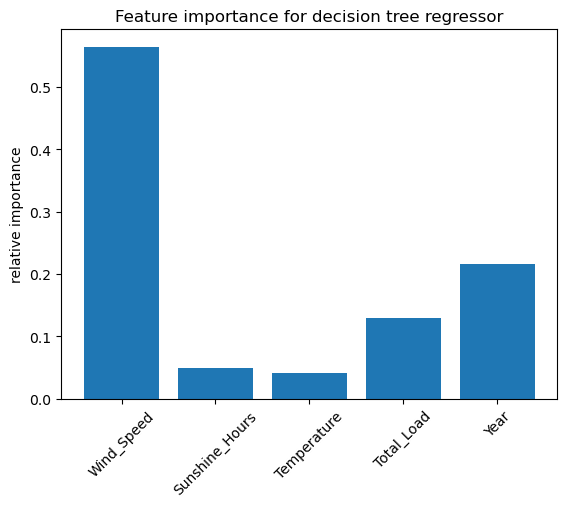

In [72]:
plt.bar(X_rl_test.columns, decisionTreeRegressor.feature_importances_);
plt.xticks(rotation=45);
plt.ylabel('relative importance')
plt.title('Feature importance for decision tree regressor')
plt.show()

Although Germany is not too big in surface area, weather conditions can differ quite significantly in different regions. Our approach of looking at meteorological data from a single city close to the geographical center is therefore an approximation only. Given that approximation, the predictive power of our model is actually not bad. It is quite conceivable that the model could be further improved, if one had available a breakdown of the residual load fraction and the meteorological variables into regions. In addition, there is a certain share of hydroelectric power, which is more steady and not modeled in this project. Including it could further improve the results.

<a id='total'></a>
### Forecasting the Total Load

Our third task is to build a forecasting model for the total power load, which enters the residual load fraction. The goal is to forecast the value of the total power load at time t, given a windows of predecessor values at time t-1, ..., t-n. We have studied recurrent neural networks for time series forecasting in our fourth capstone project, and we will leverage that experience now. We saw a clear seasonality when preparing the data, with more power load in winter. Hence we can expect a dependence of the power load on temperature, and we thus add the temperature time series as another explanatory variable. 

In [73]:
df_totalload = df_consumption[['Date','Total_Load']].copy()
df_totalload = df_totalload.join(df_weather[['Date','Temperature']].set_index('Date'), on='Date', how='inner')

Looking at the autocorrelation function of the total power load, there is not only an seasonality on an annual basis, but in addition we see a superposition of weekly seasonality patterns:

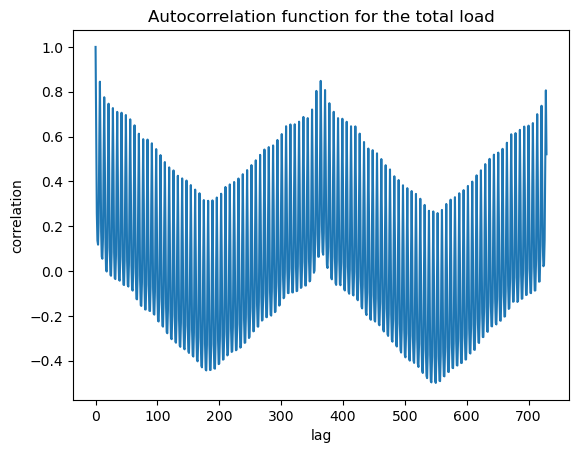

In [74]:
autocorr_tl = pd.DataFrame([[l,df_totalload.Total_Load.autocorr(lag=l)] for l in range(730)])
autocorr_tl.columns = ['lag','corr']
autocorr_tl.plot(x='lag', legend=False);
plt.ylabel('correlation')
plt.title('Autocorrelation function for the total load')
plt.show()

We therefore add the annual and weekly time information as additional explanatory variables, so that the model can learn these seasonality patterns. Also, a window size of sixty days seems like a good start that the model can learn the patterns.

In [75]:
df_totalload['Day_Of_Year'] = df_totalload['Date'].dt.dayofyear
df_totalload['Day_Of_Week'] = df_totalload['Date'].dt.weekday
df_totalload.set_index('Date', inplace=True)
df_totalload.head()

,Total_Load,Temperature,Day_Of_Year,Day_Of_Week
Date,,,,
2015-01-01,1133468.30,2.2,1,3
2015-01-02,1334453.56,4.1,2,4
2015-01-03,1258747.92,3.0,3,5
2015-01-04,1202337.75,3.3,4,6
2015-01-05,1451660.75,1.5,5,0


In [76]:
window_size = 60

Now we split the data into a training and test set.

In [77]:
X_tl_train, X_tl_test, y_tl_train, y_tl_test = train_test_split(df_totalload, df_totalload[['Total_Load']]
                                                        , test_size = 0.1, shuffle=False)

In [78]:
X_tl_train.head()

,Total_Load,Temperature,Day_Of_Year,Day_Of_Week
Date,,,,
2015-01-01,1133468.30,2.2,1,3
2015-01-02,1334453.56,4.1,2,4
2015-01-03,1258747.92,3.0,3,5
2015-01-04,1202337.75,3.3,4,6
2015-01-05,1451660.75,1.5,5,0


Next, we define a function to split the time series into rolling windows. We also apply standard scaling, so that all features and the target variable in the training set have zero mean and unit variance.

In [79]:
def split_windows(X, y, window_size):
    '''
    A function that splits a timeseries into a series of feature windows and 
    a series of continuations of these windows with the next value
    
    Args:
        values (numpy array): The timeseries to split
        window_size (int): The length of the windows
        
    Returns:
        (numpy array, numpy array): The series of feature windows and the series of continuations                                    
    '''
    windows = []
    continuations = []
    for i in range(len(X) - window_size):
        windows.append(X[i : i + window_size])
        continuations.append(y[i + window_size])
        #fund_values.append(y[i : i + window_size])
    windows = np.array(windows, dtype=np.float32)
    continuations = np.array(continuations, dtype=np.float32)
    return (windows, continuations)

In [80]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_tl_train_scaled = scaler_X.fit_transform(X_tl_train)
y_tl_train_scaled =  scaler_y.fit_transform(y_tl_train)
X_tl_test_scaled = scaler_X.transform(X_tl_test)
y_tl_test_scaled = scaler_y.transform(y_tl_test)

In [81]:
(windows_train, values_train) = split_windows(X_tl_train_scaled, y_tl_train_scaled, window_size)
x_train_tensor = torch.tensor(windows_train)
y_train_tensor = torch.tensor(values_train).flatten(1)
(windows_test, values_test) = split_windows(X_tl_test_scaled, y_tl_test_scaled, window_size)
x_test_tensor = torch.tensor(windows_test)
y_test_tensor = torch.tensor(values_test).flatten(1)

In [82]:
print(x_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([3227, 60, 4])
torch.Size([3227, 1])


We finally need to implemented torch objects for storing and loading the data, which are required to run the model training:

In [83]:
class MyDataset(Dataset):
    '''
    A class that implements the abstract torch Dataset class.
    It wraps the data and is to be used as input for the DataLoader.
    '''
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [84]:
batch_size=64
dataset_train = MyDataset(x_train_tensor, y_train_tensor)
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_test = MyDataset(x_test_tensor, y_test_tensor)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

We now set some training parameters and implement a function for model training.

In [85]:
learn_rate = 0.001
epochs = 20
criterion = nn.MSELoss(reduction='sum')

In [86]:
def train_model(model, optimizer, criterion, loader_train, loader_test, epochs):
    '''
    A function performs the model training and logs the loss functions
    
    Args:
        model (nn.Module): The model to train
        optimizer (int): Torch optimizer used in training
        loader_train (DataLoader): Loader for batched training data
        loader_test (DataLoader): Loader for batched test data
        epochs (int): Epochs to run for training
        
    Returns:
        (array, array): The loss functions for training and test data                                    
    '''
    train_losses, test_losses = [], []
    for e in range(epochs):
        running_loss = 0
        for windows, continuations in loader_train:
            windows = windows.to(device)
            continuations = continuations.to(device)
            optimizer.zero_grad()
            predictions = model.forward(windows)
            loss = criterion(predictions, continuations)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        else:
            test_loss = 0
            with torch.no_grad():
                model.eval()
                for windows, continuations in loader_test:
                    windows = windows.to(device)
                    continuations = continuations.to(device)
                    
                    predictions = model(windows)
                    test_loss += criterion(predictions, continuations).item()
            model.train()
            
            train_losses.append(running_loss/len(loader_train))
            test_losses.append(test_loss/len(loader_test))
    
            print("Epoch: {}/{}.. ".format(e+1, epochs),
                  "Training Loss: {:.6f}.. ".format((np.sqrt(running_loss))/len(loader_train.dataset)),
                  "Test Loss: {:.6f}.. ".format((np.sqrt(test_loss))/len(loader_test.dataset))
            )
    return (train_losses, test_losses)

Next, we define and train our recurrent model using two LSTM layers and a linear layer contracting the network to feature dimension. We also use a dropout value of 0.1, such that the model doesn't overfit and generalize better to the test data.

In [87]:
class ExtractTensor(nn.Module):
    '''
    The LSTM output has shape shape (batch, features, hidden).
    We need to remove the hidden output for further use with a linear layer in a sequential model.
    The required dimensionality reduction is implemented in this class
    '''
    def forward(self,x):
        # Output shape (batch, features, hidden)
        tensor, _ = x
        # Reshape shape (batch, hidden)
        return tensor[:, -1, :]

In [88]:
d_internal = 128
model_rnn = nn.Sequential(
    nn.LSTM(x_train_tensor.shape[2], d_internal, num_layers=2, dropout=0.1), 
    ExtractTensor(),
    nn.Linear(d_internal, y_train_tensor.shape[1])
).to(device)
optimizer = optim.Adam(model_rnn.parameters(), lr=learn_rate)

In [89]:
# Check number of trainable parameters
sum(p.numel() for p in model_rnn.parameters())

200833

In [90]:
(train_losses, test_losses) = train_model(model_rnn, optimizer, criterion, loader_train, loader_test, epochs)

Epoch: 1/20..  Training Loss: 0.015660..  Test Loss: 0.041328.. 
Epoch: 2/20..  Training Loss: 0.012566..  Test Loss: 0.041329.. 
Epoch: 3/20..  Training Loss: 0.012152..  Test Loss: 0.037133.. 
Epoch: 4/20..  Training Loss: 0.011823..  Test Loss: 0.035978.. 
Epoch: 5/20..  Training Loss: 0.011544..  Test Loss: 0.034764.. 
Epoch: 6/20..  Training Loss: 0.011187..  Test Loss: 0.034194.. 
Epoch: 7/20..  Training Loss: 0.010989..  Test Loss: 0.034366.. 
Epoch: 8/20..  Training Loss: 0.010774..  Test Loss: 0.033226.. 
Epoch: 9/20..  Training Loss: 0.010424..  Test Loss: 0.036352.. 
Epoch: 10/20..  Training Loss: 0.010093..  Test Loss: 0.031163.. 
Epoch: 11/20..  Training Loss: 0.009508..  Test Loss: 0.032049.. 
Epoch: 12/20..  Training Loss: 0.008563..  Test Loss: 0.024932.. 
Epoch: 13/20..  Training Loss: 0.007529..  Test Loss: 0.027495.. 
Epoch: 14/20..  Training Loss: 0.006767..  Test Loss: 0.022411.. 
Epoch: 15/20..  Training Loss: 0.006356..  Test Loss: 0.021491.. 
Epoch: 16/20..  Tra

We finally calculate predictions and errors on the test set.

In [91]:
tl_acts = scaler_y.inverse_transform(y_test_tensor.detach().cpu().numpy()[:,-1].flatten().reshape(-1, 1))
tl_exps = scaler_y.inverse_transform(model_rnn.forward(x_test_tensor).detach().cpu().numpy()[:,-1].flatten().reshape(-1, 1))
tl_residuals = tl_acts-tl_exps

In [92]:
metric = R2Score()
metric.update(model_rnn.forward(x_test_tensor), y_test_tensor)
metric.compute()

tensor(0.8208)

In [93]:
print(f'Mean absolute error: {np.mean(np.abs(tl_exps-tl_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(tl_exps/tl_acts-1))}')

Mean absolute error: 37607.72265625
Mean abs of relative errors base: 0.030390966683626175


The model does a really good job on the test data, with an R-squared of over 80%, and mean absolute error of around 38k MWh, and a mean relative error of only 3%. This is also confirmed in the visualization of the time series below:

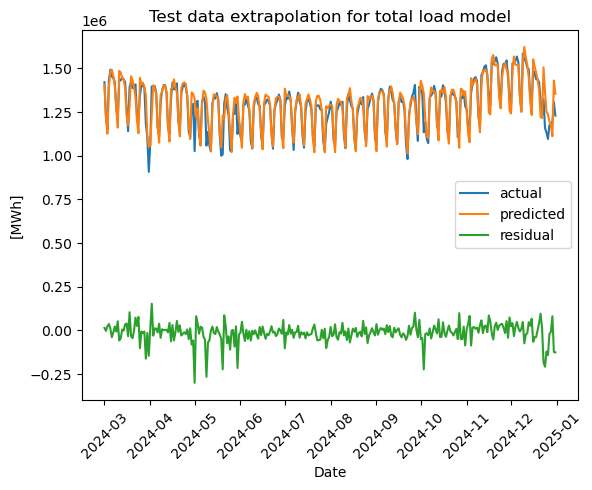

In [94]:
plt.plot(X_tl_test.index[window_size:], tl_acts, label ='actual');
plt.plot(X_tl_test.index[window_size:], tl_exps, label ='predicted');
plt.plot(X_tl_test.index[window_size:], tl_residuals, label ='residual');
plt.legend()
plt.xticks(rotation=45);
plt.xlabel('Date')
plt.ylabel('[MWh]')
plt.title('Test data extrapolation for total load model')
plt.show()

We finally look at the loss curves for training and test set. This reveals an interesting pattern: The model starts learning fast in the first two epochs, then slows down until around epoch ten before making another leap between epoch ten and fifteen. After 20 epochs, we see that training has converged:

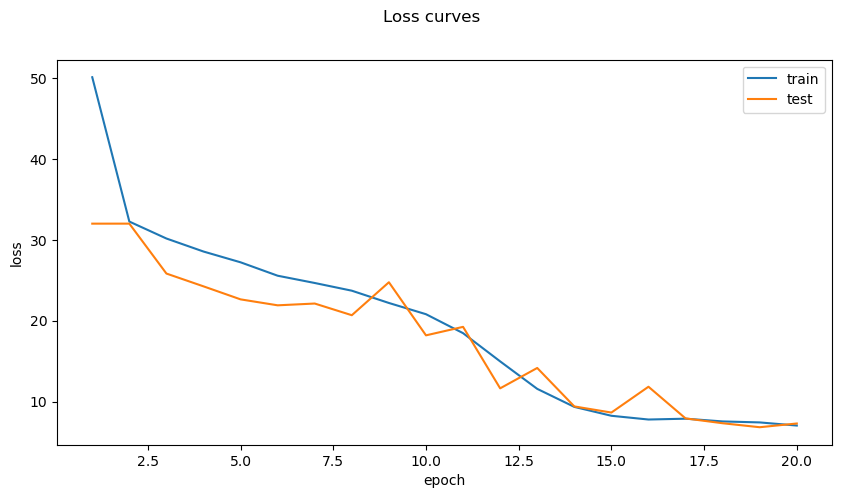

In [95]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Loss curves')
ax.plot(range(1,epochs+1), train_losses, label="train")
ax.plot(range(1,epochs+1), test_losses, label="test")
ax.set(xlabel='epoch', ylabel='loss')
ax.legend(loc="upper right")
plt.show()

<a id='flows'></a>
### Workflows and Use Cases

TODO

<a id='lim'></a>
### Limitations and Future Improvements

TODO

<a id='summary'></a>
### Summary

TODO

In [96]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt